# Example: SIM Portfolios with a Risk-Free Asset, the Tangent Portfolio, and the Capital Allocation Line
In this example, we add a horizon-matched risk-free asset to the single index model (SIM) inputs of the first example. We solve the risky and risk-free allocation problem the way the course package poses it, show that its solutions for every target growth rate lie on one ray from the risk-free asset (the capital allocation line), read the tangent portfolio off that ray, compare it with the tangent portfolio the data-driven inputs select, and then score complete portfolios that lend or borrow against the tangent portfolio on 2025 data.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Solve the risky and risk-free problem with SIM inputs:__ Build the SIM mean vector and covariance from the archive, sweep the target growth rate with the package's risky and risk-free solver, and verify that every solution is a multiple of one risky weight vector, so that the risk-free fraction alone moves along the capital allocation line.
> * __Find and compare the tangent portfolio:__ Normalize any solution on the ray to obtain the tangent portfolio, cross-check it against the maximum-Sharpe point of the risky-only frontier, quote its Sharpe ratio in both conventions, and compare it with the data-driven tangent portfolio.
> * __Score complete portfolios out of sample:__ Form complete portfolios that lend part of the wealth at the risk-free rate, hold the tangent portfolio outright, or borrow against it, and compare their modeled and realized 2025 growth and risk with an index fund.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, and so is the data-driven comparison below. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), used only in the last task.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days, and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive `SIMs-SP500-01-03-14-to-12-31-24.jld2` from the L6a estimation example [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/): per security the estimated intercept $\hat{\alpha}_{i}$, beta $\hat{\beta}_{i}$, and residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (fields `alpha`, `beta`, `training_variance`), and once for the archive the training-period market mean $g^{\prime}_{M}$ and variance $s^{2}_{g,M}$ (keys `market_mean`, `market_variance`). We store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the market moments in `g_market_mean::Float64` and `σ²_market::Float64`:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

### Constants
Finally, let's specify some constants that we will use in our analysis. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024 (decision date, horizon matched to the 2025 test year), as in L5b
W₀ = 1000.0; # initial wealth (units: USD)
number_of_points = 101; # number of target growth rates in each sweep
g_target_max = 0.60; # largest target growth rate in the risky and risk-free sweep (units: 1/years)
risk_free_fractions = [0.75, 0.50, 0.25, 0.0, -0.25]; # risk-free fraction w_f of the complete portfolios in the last task (negative = borrowing)

___

## Task 1: The Inputs
We use the same thirteen firms as L5b and the first example (change the list if you like; the list is fixed before 2025). Specify the ticker symbols in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b

We assemble the SIM inputs exactly as in the first example, $\hat{\mathbf{g}}_{\text{SIM}}=\hat{\boldsymbol{\alpha}}+\hat{\boldsymbol{\beta}}\,g^{\prime}_{M}$ and $\hat{\mathbf{\Sigma}}_{g,\text{SIM}}=s^{2}_{g,M}\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top}+\hat{\mathbf{D}}_{g}$, with the training-period market moments from the archive, and we also compute the data-driven inputs $\hat{\mathbf{g}}$ and $\hat{\mathbf{\Sigma}}_{g}$ from the training growth-rate matrix (L5b) for the comparison in the next task. The first example showed that $\hat{\mathbf{g}}_{\text{SIM}}=\hat{\mathbf{g}}$ exactly; we assert it again. We store the inputs in the `ĝ_sim`, `Σ̂_g_sim`, `ĝ`, and `Σ̂_g` variables and the betas in `β̂::Array{Float64,1}`:

In [7]:
ĝ_sim, Σ̂_g_sim, ĝ, Σ̂_g, β̂ = let

    # check: the chosen firms share the same trading dates (rows are aligned by position) -
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end

    # SIM inputs from the archive -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    # data-driven inputs from the training growth-rate matrix (L5b) -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # growth rates g (units: 1/years)
    ĝ = mean(G, dims=1) |> vec; # sample-mean growth rates (units: 1/years)
    Σ̂_g = cov(G, dims=1); # growth-rate covariance (units: 1/years²)

    @assert isapprox(ĝ_sim, ĝ, rtol = 1e-8) # the SIM mean vector reproduces the sample means (first example)
    @assert isposdef(Σ̂_g_sim) && isposdef(Σ̂_g)
    (ĝ_sim, Σ̂_g_sim, ĝ, Σ̂_g, β̂); # return
end;

___

## Task 2: The Capital Allocation Line and the Tangent Portfolio
The lecture writes the risky and risk-free problem the way the course package solves it: minimize the growth-rate variance $\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g,\text{SIM}}\mathbf{w}$ over the risky weights $\mathbf{w}$, with $0\leq w_{i}\leq 1$, subject to the growth constraint $\hat{\mathbf{g}}_{\text{SIM}}^{\top}\mathbf{w}+(1-\mathbf{1}^{\top}\mathbf{w})\,g_{f}\geq g_{\star}$, where the risk-free fraction $w_{f}=1-\mathbf{1}^{\top}\mathbf{w}$ is whatever the risky weights leave over and may be negative (borrowing at $g_{f}$). Eliminating $w_{f}$ turns the growth constraint into a constraint on the excess growth rate, $(\hat{\mathbf{g}}_{\text{SIM}}-g_{f}\mathbf{1})^{\top}\mathbf{w}\geq g_{\star}-g_{f}$, and because the objective is homogeneous of degree two and this constraint of degree one, the minimizer for every feasible target above $g_{f}$ is the __same__ risky direction scaled up or down (unique because $\hat{\mathbf{\Sigma}}_{g,\text{SIM}}$ is positive definite, and valid until an upper bound $w_{i}\leq1$ binds): the solutions lie on a ray from the risk-free asset. The point on the ray with $\mathbf{1}^{\top}\mathbf{w}=1$ is the tangent portfolio $\mathcal{T}$.

Let's see it. We create an instance of [the `MyMarkowitzRiskyRiskFreePortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyRiskFreePortfolioChoiceProblem) [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyRiskFreePortfolioChoiceProblem},%20NamedTuple}) (fields `Σ`, `μ`, `bounds`, `initial`, `R`, and `risk_free_rate`), sweep the target $g_{\star}$ from $g_{f}$ to `g_target_max`, and at each target record the achieved expected growth rate, the growth-rate standard deviation, the risky fraction $\mathbf{1}^{\top}\mathbf{w}$, and the weights [using the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyRiskFreePortfolioChoiceProblem}). We store the sweep in the `cal_df::DataFrame` variable:

In [8]:
cal_df = let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1 on the risky weights; w_f = 1 - 1ᵀw is free
    problem = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (
        Σ = Σ̂_g_sim, # SIM growth-rate covariance matrix
        μ = ĝ_sim, # package field μ holds the expected growth rates
        bounds = bounds, # bounds on the risky weights
        initial = (1/number_of_assets)*ones(number_of_assets), # start from equal weights
        risk_free_rate = g_f, # risk-free growth rate g_f
        R = g_f # target growth rate g⋆ (updated in the loop)
    ));
    df = DataFrame(g_target = Float64[], g = Float64[], σ = Float64[], risky_fraction = Float64[], w = Vector{Float64}[]);
    for target ∈ range(g_f, stop = g_target_max, length = number_of_points)
        problem.R = target;
        try
            solution = solve(problem);
            if (solution["status"] == MathOptInterface.LOCALLY_SOLVED)
                w = solution["argmax"];
                push!(df, (g_target = target, g = solution["reward"], σ = sqrt(w'*Σ̂_g_sim*w), risky_fraction = sum(w), w = w));
            end
        catch err
            err isa AssertionError || rethrow()
        end
    end
    df; # return
end;
println("solved $(nrow(cal_df)) of $(number_of_points) targets; risky fraction runs from $(round(cal_df.risky_fraction[1], digits=3)) to $(round(cal_df.risky_fraction[end], digits=3)); largest single weight $(round(maximum(maximum.(cal_df.w)), digits=3))")

solved 101 of 101 targets; risky fraction runs from 0.0 to 1.582; largest single weight 0.849


Now the two checks. First, every solution should be a multiple of one risky direction: we normalize each weight vector by its risky fraction (skipping solutions with less than one percent of wealth in risky assets, because at $g_{\star}=g_{f}$ the solution is $\mathbf{w}=\mathbf{0}$ and just above it the weights sit at the solver's tolerance) and measure how far the normalized vectors are from the one at the largest target, which has the least relative rounding. Second, the tangent portfolio is that common direction normalized to sum to one, and it should be the maximum-Sharpe point of the risky-only frontier: we trace the SIM risky-only frontier with the same sweep as the first example, evaluate the Sharpe ratio $(\mathbb{E}[g_{p}]-g_{f})/\sigma_{g,p}$ at every point, and compare the largest with the tangent portfolio's. We store the tangent portfolio in the `w_tan_sim::Array{Float64,1}` variable:

In [9]:
w_tan_sim = let
    directions = [w / sum(w) for w ∈ cal_df.w if sum(w) > 1e-2]; # normalized risky directions along the ray (at least 1% in risky assets)
    spread = maximum(maximum(abs.(d .- directions[end])) for d ∈ directions);
    println("$(length(directions)) solutions normalized; max deviation of the normalized risky weights from the largest-target solution: $(spread) (one direction for every target)")
    @assert spread < 1e-4
    @assert maximum(maximum.(cal_df.w)) < 1.0 - 1e-6 # no upper bound is active anywhere in the sweep, so the ray has no kink
    directions[end]; # the tangent portfolio: the common direction, normalized to sum to one
end;

# cross-check against the risky-only frontier -
let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = minimum(ĝ_sim)));
    g_low = ĝ_sim'*solve(problem)["argmax"];
    best = (SR = -Inf, g = NaN, σ = NaN);
    for target ∈ range(g_low, stop = maximum(ĝ_sim) - 1e-4, length = number_of_points)
        problem.R = target;
        try
            w = solve(problem)["argmax"]; g = ĝ_sim'*w; σ = sqrt(w'*Σ̂_g_sim*w); SR = (g - g_f)/σ;
            SR > best.SR && (best = (SR = SR, g = g, σ = σ));
        catch err
            err isa AssertionError || rethrow()
        end
    end
    g_tan = ĝ_sim'*w_tan_sim; σ_tan = sqrt(w_tan_sim'*Σ̂_g_sim*w_tan_sim); SR_tan = (g_tan - g_f)/σ_tan;
    println("tangent portfolio from the ray:      E[g] = $(round(g_tan, digits=4)) 1/yr, σ_g = $(round(σ_tan, digits=4)) 1/yr, SR = $(round(SR_tan, digits=4))")
    println("largest Sharpe ratio on the frontier: E[g] = $(round(best.g, digits=4)) 1/yr, σ_g = $(round(best.σ, digits=4)) 1/yr, SR = $(round(best.SR, digits=4)) (agreement to the resolution of the frontier grid)")
    @assert SR_tan ≥ best.SR - 1e-4
end

100 solutions normalized; max deviation of the normalized risky weights from the largest-target solution: 2.3905653848688146e-6 (one direction for every target)
tangent portfolio from the ray:      E[g] = 0.3944 1/yr, σ_g = 4.2382 1/yr, SR = 0.0834
largest Sharpe ratio on the frontier: E[g] = 0.393 1/yr, σ_g = 4.2222 1/yr, SR = 0.0834 (agreement to the resolution of the frontier grid)


How does the SIM tangent portfolio compare with the one the data-driven inputs select? For the data inputs there is no closed form under the long-only constraint, so as in L5b we evaluate the Sharpe ratio along the data-driven long-only frontier and take the largest. Let's put the two weight vectors side by side with the betas, and quote each Sharpe ratio both ways: in growth-rate units (the CAL slope, a one-day holding period) and annualized, $\text{SR}/\sqrt{\Delta{t}}$, the convention we quote from here on:

In [10]:
w_tan_data = let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g, μ = ĝ, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = minimum(ĝ)));
    g_low = ĝ'*solve(problem)["argmax"];
    best = (SR = -Inf, w = zeros(number_of_assets));
    for target ∈ range(g_low, stop = maximum(ĝ) - 1e-4, length = number_of_points)
        problem.R = target;
        try
            w = solve(problem)["argmax"]; SR = (ĝ'*w - g_f)/sqrt(w'*Σ̂_g*w);
            SR > best.SR && (best = (SR = SR, w = w));
        catch err
            err isa AssertionError || rethrow()
        end
    end
    best.w; # data-driven long-only tangent portfolio (grid candidate, as in L5b)
end;

let
    df = DataFrame(ticker = my_list_of_tickers, β̂ = round.(β̂, digits=2), w_tan_SIM = round.(w_tan_sim, digits=4) .+ 0.0, w_tan_data = round.(w_tan_data, digits=4) .+ 0.0);
    push!(df, (ticker = "sum", β̂ = NaN, w_tan_SIM = round(sum(w_tan_sim), digits=4), w_tan_data = round(sum(w_tan_data), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    for (name, w, g_vector, Σ_matrix) ∈ [("SIM inputs ", w_tan_sim, ĝ_sim, Σ̂_g_sim), ("data inputs", w_tan_data, ĝ, Σ̂_g)]
        g = g_vector'*w; σ = sqrt(w'*Σ_matrix*w); SR = (g - g_f)/σ;
        println("Tangent ($(name)): β_p = $(round(β̂'*w, digits=3)), E[g] = $(round(g, digits=4)) 1/yr, σ_g = $(round(σ, digits=4)) 1/yr, SR = $(round(SR, digits=4)) (one-day interval), annualized SR = $(round(SR/sqrt(Δt), digits=3))")
    end
end

 -------- --------- ----------- ------------
  ticker         β̂   w_tan_SIM   w_tan_data 
  String   Float64     Float64      Float64 
 -------- --------- ----------- ------------
    AAPL      1.19      0.2027       0.2013
    MSFT      1.15      0.2203       0.1254
    INTC      1.18         0.0          0.0
      MU       1.7         0.0          0.0
     AMD      1.74      0.0405          0.0
    NVDA      1.75      0.5364       0.6733
      GS      1.31         0.0          0.0
     BAC      1.36         0.0          0.0
     WFC      1.24         0.0          0.0
       C       1.5         0.0          0.0
       F      1.43         0.0          0.0
      GM      1.47         0.0          0.0
     JNJ      0.54         0.0          0.0
     sum       NaN         1.0          1.0
 -------- --------- ----------- ------------
Tangent (SIM inputs ): β_p = 1.505, E[g] = 0.3944 1/yr, σ_g = 4.2382 1/yr, SR = 0.0834 (one-day interval), annualized SR = 1.324
Tangent (data inputs): β_p = 

Both tangent portfolios hold the same three large high-growth technology names and nothing else except a small semiconductor position that only the SIM version takes, with a portfolio beta well above one; the SIM version is less concentrated in the single best firm and more spread across the group, which is what its flatter correlation structure implies. Both Sharpe ratios are training-period numbers under each model's own covariance, not forecasts.

Let's draw the picture: the SIM risky-only efficient frontier, the capital allocation line through the SIM tangent portfolio (solid for lending, $0<w_{f}<1$; dashed for borrowing, $w_{f}<0$), the risk-free asset, and the single firms. `Unhide` the code block below to see how:

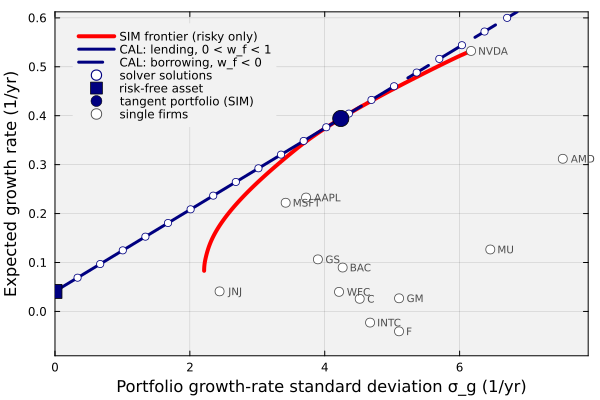

In [11]:
let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = minimum(ĝ_sim)));
    g_low = ĝ_sim'*solve(problem)["argmax"];
    σ_front = Float64[]; g_front = Float64[];
    for target ∈ range(g_low, stop = maximum(ĝ_sim) - 1e-4, length = number_of_points)
        problem.R = target;
        try
            w = solve(problem)["argmax"]; push!(g_front, ĝ_sim'*w); push!(σ_front, sqrt(w'*Σ̂_g_sim*w));
        catch err
            err isa AssertionError || rethrow()
        end
    end
    σ_single = sqrt.(diag(Σ̂_g_sim));
    g_tan = ĝ_sim'*w_tan_sim; σ_tan = sqrt(w_tan_sim'*Σ̂_g_sim*w_tan_sim); SR_tan = (g_tan - g_f)/σ_tan;
    σ_max = 1.05*maximum(σ_single);

    plot(σ_front, g_front, lw = 4, c = :red, label = "SIM frontier (risky only)")
    plot!([0.0, σ_tan], [g_f, g_tan], lw = 3, c = :navy, label = "CAL: lending, 0 < w_f < 1")
    plot!([σ_tan, σ_max], [g_tan, g_f + SR_tan*σ_max], lw = 3, ls = :dash, c = :navy, label = "CAL: borrowing, w_f < 0")
    scatter!(cal_df.σ[1:5:end], cal_df.g[1:5:end], ms = 4, c = :white, msc = :navy, label = "solver solutions")
    scatter!([0.0], [g_f], ms = 7, c = :navy, marker = :square, label = "risk-free asset")
    scatter!([σ_tan], [g_tan], ms = 9, c = :navy, label = "tangent portfolio (SIM)")
    scatter!(σ_single, ĝ_sim, ms = 5, c = :white, msc = :gray30, label = "single firms")
    for i ∈ 1:number_of_assets
        annotate!(σ_single[i] + 0.12, ĝ_sim[i], text(my_list_of_tickers[i], 7, :left, :gray30))
    end
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)",
        xlim = (0.0, σ_max), ylim = (min(0.0, minimum(ĝ_sim)) - 0.05, maximum(ĝ_sim) + 0.08),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

The solver's solutions fall on the line, below the tangent portfolio while the target is small (part of the wealth lent at $g_{f}$) and beyond it once the target exceeds the tangent portfolio's expected growth rate (borrowing at $g_{f}$ to hold more than the whole budget in $\mathcal{T}$). Everything on this line is a statement about the linearized one-period growth rate; the next task evaluates the same positions with the buy-and-hold wealth rule.
___

## Task 3: Complete Portfolios Out of Sample
Two-fund separation says every investor holds the same risky fund and differs only in the risk-free fraction $w_{f}$. Let's take that literally: for each $w_{f}$ in `risk_free_fractions` we form the complete portfolio that puts $w_{f}$ of the initial wealth in the risk-free asset and $1-w_{f}$ in the SIM tangent portfolio; a negative $w_{f}$ borrows that fraction of the initial wealth at $g_{f}$ and invests it in $\mathcal{T}$ as well. Under the model the complete portfolio has $\mathbb{E}[g_{c}]=g_{f}+(1-w_{f})(\mathbb{E}[g_{\mathcal{T}}]-g_{f})$ and $\sigma_{g,c}=|1-w_{f}|\,\sigma_{g,\mathcal{T}}$ (L5b). Out of sample, with the risky leg held buy-and-hold at the tangent weights and the risk-free leg (or the loan) growing at $g_{f}$, the wealth on 2025 trading day $t$ (in years since the first day) is:
$$
W_{t} = W_{0}\left[w_{f}\,e^{g_{f}t} + (1-w_{f})\sum_{i\in\mathcal{P}}w_{\mathcal{T},i}\,\frac{S_{i}(t)}{S_{i}(0)}\right]
$$
which for $w_{f}<0$ subtracts the loan and its interest (borrowing at the Treasury rate is the same idealization as in L5b; a real loan costs more). Two things to keep in mind: the comparison is price-only (volume-weighted average prices, no dividends, for the firms and for SPY), and these are __initial__ weights held buy-and-hold, so the risky weights and the risk-free fraction drift during the year and the path is not continuously rebalanced to a fixed point on the line. We use the same first trading day and $W_{0}$ for every portfolio, and add the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500) for reference. We store the wealth paths in the `wealth_2025::Dict{String,Array{Float64,1}}` variable:

In [12]:
wealth_2025 = let
    N = nrow(dataset_2025["AAPL"]);
    S = hcat([dataset_2025[ticker][:, :volume_weighted_average_price] for ticker ∈ my_list_of_tickers]...); # 2025 prices, one column per firm
    risky_ratio = (S ./ S[1,:]')*w_tan_sim; # buy-and-hold wealth ratio of the tangent portfolio
    t = (0:(N-1)) .* Δt; # years since the first 2025 trading day (t = 0 on the first day)
    wealth = Dict{String, Array{Float64,1}}();
    for w_f ∈ risk_free_fractions
        @assert (1 - w_f)*maximum(w_tan_sim) ≤ 1.0 # the initial dollar position in every firm stays within the solver's bounds, even when borrowing
        W = W₀ .* (w_f .* exp.(g_f .* t) .+ (1 - w_f) .* risky_ratio); # complete portfolio
        @assert all(W .> 0) # a borrower's wealth stayed positive, so the log growth below is defined
        wealth["w_f = $(w_f)"] = W;
    end
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price];
    wealth["SPY"] = W₀*(spy ./ spy[1]);
    wealth; # return
end;

Let's plot the scaled wealth paths, $W_{t}/W_{0}$, over the 2025 trading days. `Unhide` the code block below to see how:

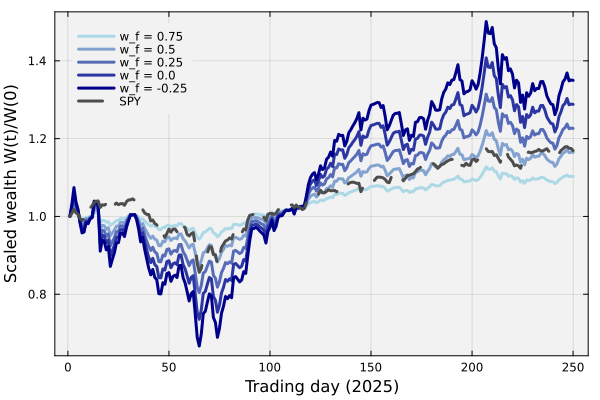

In [13]:
let
    p = plot();
    colors = cgrad(:blues, length(risk_free_fractions), categorical = true);
    for (k, w_f) ∈ enumerate(risk_free_fractions)
        plot!(wealth_2025["w_f = $(w_f)"] ./ W₀, lw = 3, c = colors[k], label = "w_f = $(w_f)")
    end
    plot!(wealth_2025["SPY"] ./ W₀, lw = 3, c = :gray30, ls = :dash, label = "SPY")
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

Finally, the scorecard: for each complete portfolio the modeled expected growth rate and growth-rate standard deviation from the CAL, next to the realized 2025 growth rate $\ln(W_{T}/W_{0})/T$ and the realized growth-rate standard deviation of the wealth path (daily log growth of wealth, in the same units), [using the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff):

In [14]:
let
    g_tan = ĝ_sim'*w_tan_sim; σ_tan = sqrt(w_tan_sim'*Σ̂_g_sim*w_tan_sim);
    df = DataFrame(portfolio = String[], model_g = Float64[], model_σ_g = Float64[], W_T_over_W_0 = Float64[], growth_2025 = Float64[], σ_g_2025 = Float64[]);
    for w_f ∈ risk_free_fractions
        W = wealth_2025["w_f = $(w_f)"]; T = (length(W) - 1)*Δt;
        g_daily = diff(log.(W)) ./ Δt;
        push!(df, (portfolio = "w_f = $(w_f)", model_g = round(g_f + (1 - w_f)*(g_tan - g_f), digits=4), model_σ_g = round(abs(1 - w_f)*σ_tan, digits=3),
            W_T_over_W_0 = round(W[end]/W[1], digits=4), growth_2025 = round(log(W[end]/W[1])/T, digits=4), σ_g_2025 = round(std(g_daily), digits=3)));
    end
    W = wealth_2025["SPY"]; T = (length(W) - 1)*Δt; g_daily = diff(log.(W)) ./ Δt;
    push!(df, (portfolio = "SPY", model_g = NaN, model_σ_g = NaN, W_T_over_W_0 = round(W[end]/W[1], digits=4), growth_2025 = round(log(W[end]/W[1])/T, digits=4), σ_g_2025 = round(std(g_daily), digits=3)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------- --------- ----------- -------------- ------------- ----------
    portfolio   model_g   model_σ_g   W_T_over_W_0   growth_2025   σ_g_2025 
       String   Float64     Float64        Float64       Float64    Float64 
 ------------- --------- ----------- -------------- ------------- ----------
   w_f = 0.75    0.1293        1.06          1.103        0.0992      1.148
    w_f = 0.5    0.2177       2.119         1.1647        0.1543      2.292
   w_f = 0.25     0.306       3.179         1.2263        0.2065      3.452
    w_f = 0.0    0.3944       4.238          1.288        0.2561      4.647
  w_f = -0.25    0.4827       5.298         1.3497        0.3035      5.899
          SPY       NaN         NaN         1.1691        0.1581      2.206
 ------------- --------- ----------- -------------- ------------- ----------


Read the two halves of the table separately. The __risk__ column behaves as the CAL says it should: the realized standard deviation scales almost exactly with $1-w_{f}$, because the risk-free leg contributes no variance and the risky leg is one fixed portfolio. Not exactly, though: the CAL's scaling is exact for the linearized one-period statistic, while a buy-and-hold mixture drifts during the year, so the daily log growth of wealth is only approximately a fixed multiple of the tangent portfolio's. The __growth__ column does not match the model, and it should not be expected to: the modeled expected growth rate is the 2014 to 2024 estimate of the tangent portfolio's growth, the least certain input in the whole problem (L5b), while the realized column is one year of one path. In this year the tangent portfolio's growth fell short of its estimate and the leveraged position amplified both the growth and the standard deviation, exactly as the ray predicts. None of this is a recommendation for any $w_{f}$; the choice of $w_{f}$ is the investor's risk tolerance, and the model tells them only what each choice trades off.
___

## Summary
In this example, we added a horizon-matched risk-free asset to the single index model inputs, showed that the package's risky and risk-free solutions for every target growth rate lie on one ray from the risk-free asset, read the tangent portfolio off that ray and confirmed it against the maximum-Sharpe point of the risky-only frontier, compared it with the data-driven tangent portfolio, and scored complete portfolios that lend, hold, or borrow against it on 2025 data.

> __Key Takeaways:__
>
> * **The risky and risk-free problem has one risky answer:** Because the risk-free fraction is whatever the risky weights leave over, the growth constraint is a constraint on excess growth, and every target selects the same risky direction scaled by the target; the fully invested point on that ray is the tangent portfolio, and beyond it the solver borrows at the risk-free rate.
> * **SIM and data inputs pick similar tangent portfolios:** Both concentrate in the same three high-growth technology names with a portfolio beta well above one; the SIM version is less concentrated and adds a small semiconductor position, and both Sharpe ratios (about 1.3 annualized) are training-period numbers under each model's own covariance.
> * **The CAL's risk scaling nearly survives out of sample, its growth does not:** The realized 2025 standard deviation of each complete portfolio scales almost exactly with the risky fraction as the line predicts (a drifting buy-and-hold mixture is not a maintained one), while realized growth depends on whether the tangent portfolio's estimated growth rate persisted, which is the input least likely to.

The lecture's closing section and the optional advanced notebook ask the next question: how much do these portfolios move when the SIM parameters themselves are uncertain?
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___